# Plot Zero-Variance extrapolation - 1D chain L = 20

In [7]:
import glob
import os
import sys

In [8]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
verbose = True

In [10]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [11]:
dossiers = glob.glob("../../datas/2D_4x4_frustrated/datas_alpha_iter_*") 

In [12]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(
    data_dict_AL, 
    mc_results_AL, 
    L, 
    save_dir="../../assets/2D_4x4_frustrated", 
    name="AL_extrapolation"
)

plot_extrapolation_distribution(
    data_dict_AL, mc_results_AL, 
    save_dir="../../assets/2D_4x4_frustrated", 
    name="AL_distribution"
)

Loading and processing 2 folders...
✅ Loading complete: 0 simulations processed!


ValueError: ERREUR : Aucune simulation n'a été chargée ! Vérifie que les dossiers existent et contiennent bien les fichiers JSON.

In [ ]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    100   -0.558522 0.015570 0.012478       -0.561089     0.001232     0.003510
    150   -0.558377 0.017342 0.013169       -0.561148     0.001190     0.003449
    200   -0.558726 0.015457 0.012433       -0.561145     0.001334     0.003652


## Krylov Subspace 

In [ ]:
dossiers = glob.glob("../../datas/2D_4x4_frustrated/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.42289617
Extrapolated Energy       : -0.43294007 ± 0.00684961
95% Confidence Interval   : [-0.44920456 , -0.42302066]
Absolute Error vs Exact   : 1.00e-02


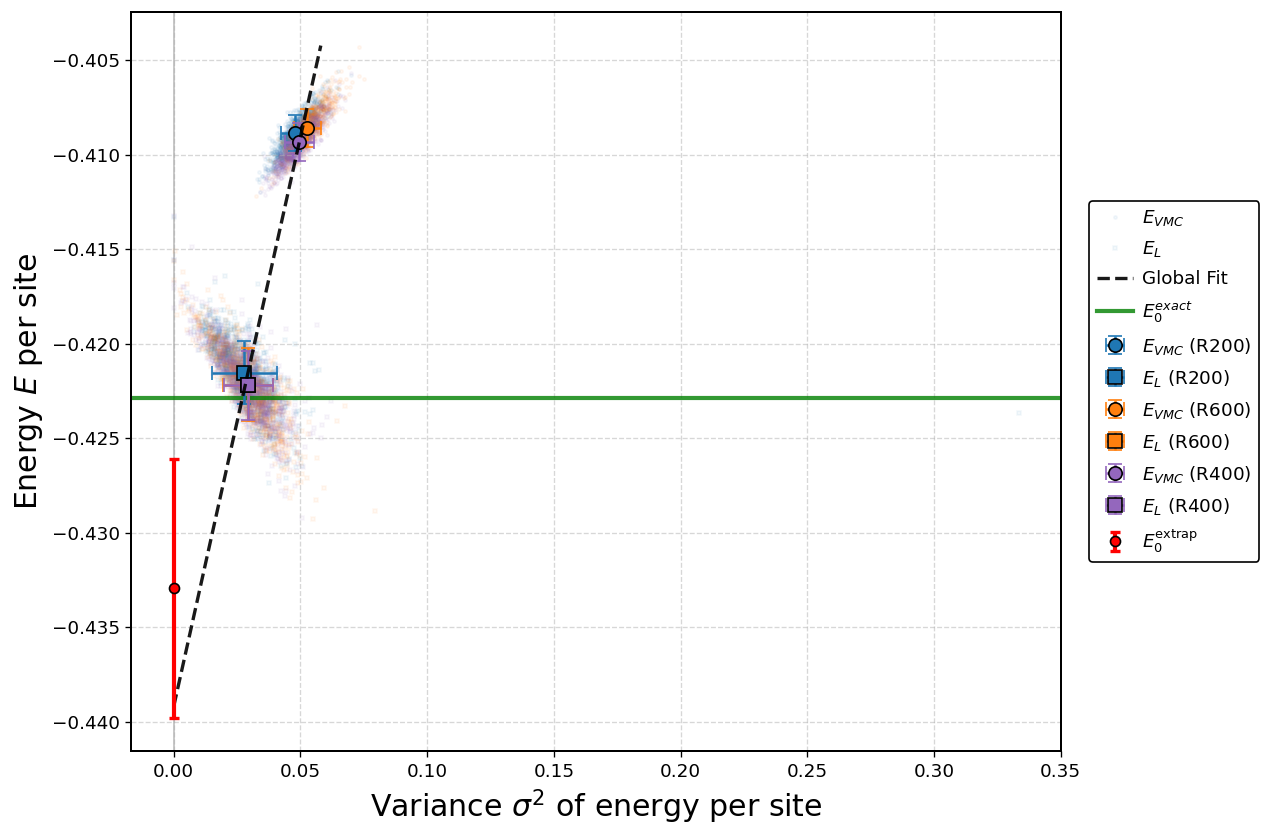

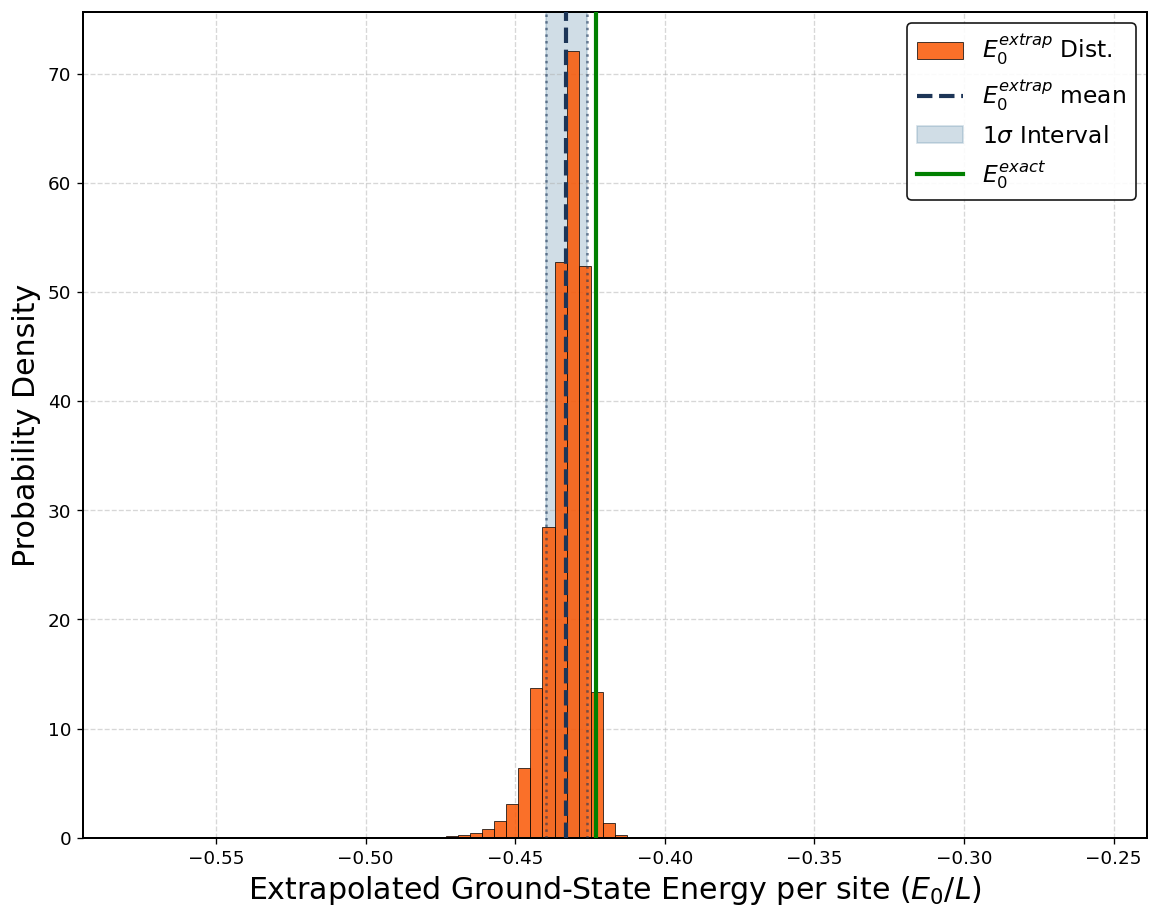

In [ ]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets/2D_4x4_frustrated", name="Krylov_extrapolation")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets/2D_4x4_frustrated", name="Krylov_distribution")

In [ ]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    200   -0.408869 0.047661 0.006904       -0.421541     0.027832     0.005276
    400   -0.409345 0.049584 0.007042       -0.422216     0.029441     0.005426
    600   -0.408604 0.052763 0.007264       -0.422170     0.029160     0.005400


## Comparaison 

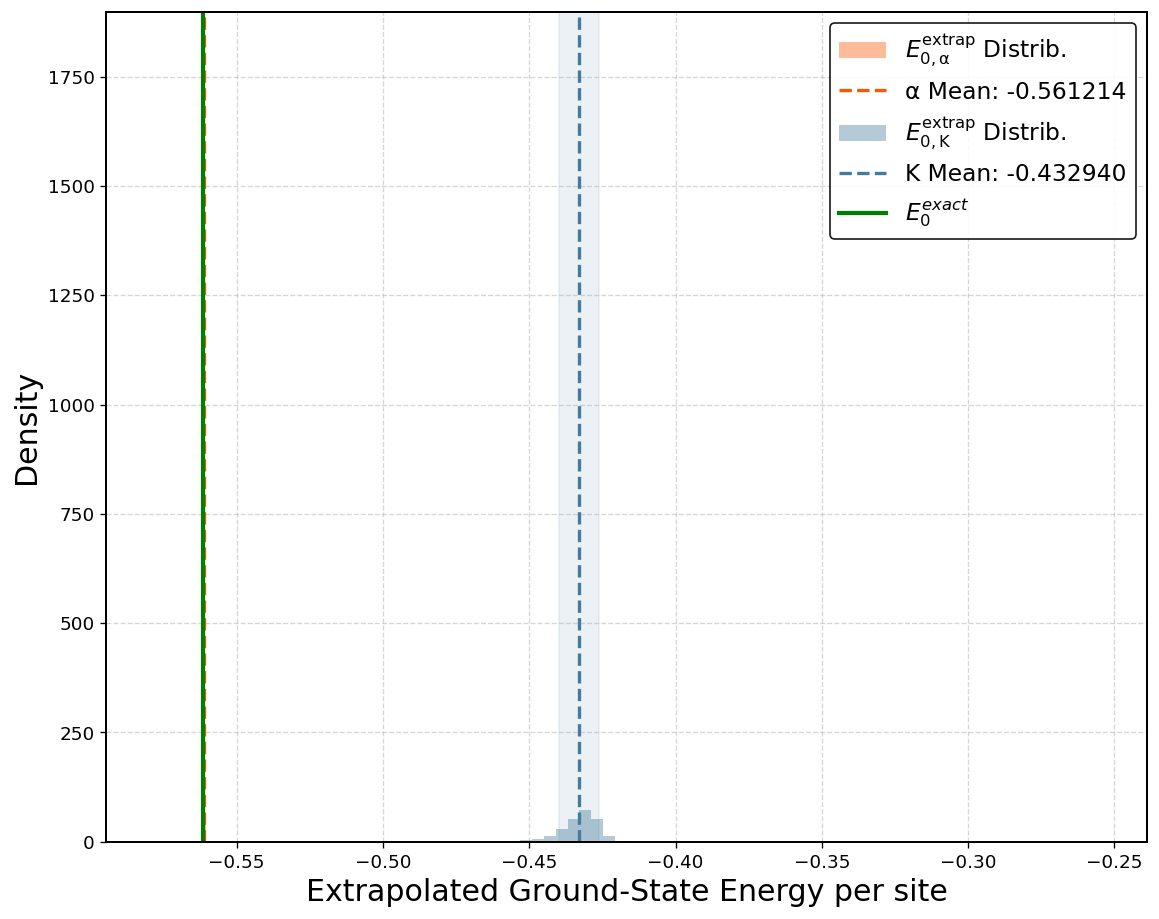

In [ ]:
mes_distributions = {
    "α": mc_results_AL,
    "K": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets/2D_4x4_frustrated")